<div style="text-align: center; padding: 40px; line-height: 1.2;">
    <p style="font-size: 40px; font-weight: bold; color: #2E4053; margin: 0;">
       Anexo I: Fase Preliminar Obligatoria
    </p>
    <p style="font-size: 25px; color: #5D6D7E; margin: 10px 0 20px 0;">
         Resolución de ecuaciones en derivadas parciales: la ecuación de
Schrodinger
    </p>
    <hr style="border: 0; border-top: 2px solid #AEB6BF; width: 60%; margin: auto;">
    <p style="font-size: 20px; font-weight: bold; margin-top: 30px; color: black;">
        Claudia González Arnaiz, DNI: 78242238X
    </p>
    <p style="font-size: 16px; color: #566573; margin-top: 5px;">
        Física Computacional - Curso 2025/26
    </p>
</div>

# Introducción y contexto de la fase obligatoria

En este cuaderno se desarrolla la parte Obligatoria de la práctica, cuyo objetivo principal es implementar y validar el método numérico necesario para resolver la ecuación de Schrödinger dependiente del tiempo. Este bloque constituye la base sobre la que se construye posteriormente el análisis más completo realizado en la parte voluntaria.

Se ha decidido presentar esta fase en un documento independiente con el fin de mantener una estructura clara y evitar una excesiva extensión en la memoria principal. No obstante, ambos trabajos están estrechamente relacionados, ya que comparten el mismo enfoque numérico y las mismas herramientas computacionales.

En particular, para la realización de esta fase se han empleado:
* **Lenguaje y librerías:** Python, utilizando NumPy para el cálculo numérico y Matplotlib para la visualización de resultados.
* **Entorno de trabajo:** Cuaderno Jupyter, que permite combinar código, resultados y explicación teórica en un mismo documento.

## Justificación de esta fase

Esta fase obligatoria tiene como objetivo validar el correcto funcionamiento del método de evolución temporal (basado en la aproximación de Cayley) y comprobar que el algoritmo reproduce propiedades físicas fundamentales del sistema.

Antes de abordar el estudio más completo del oscilador armónico en la parte voluntaria, es necesario verificar que:
- La norma de la función de onda se conserva.
- La evolución temporal es estable.
- Los resultados son físicamente consistentes.

De este modo, esta etapa actúa como un paso previo indispensable que garantiza la fiabilidad del método numérico empleado. Una vez validado el algoritmo, se procede en la parte voluntaria a realizar un análisis más profundo del sistema, incluyendo el estudio de observables, comparaciones con el caso clásico y la verificación del principio de correspondencia.

# Fundamento teórico

En esta fase se aborda la resolución numérica de la ecuación de Schrödinger dependiente del tiempo en una dimensión:

$$
i \frac{\partial \phi(x,t)}{\partial t} = H \phi(x,t)
$$

donde $H$ es el operador Hamiltoniano del sistema, que en este caso incluye un término cinético y un potencial. La ecuación describe la evolución temporal de la función de onda, cuya magnitud al cuadrado representa la densidad de probabilidad de encontrar la partícula en una posición dada.

Para resolver esta ecuación se discretiza el espacio y el tiempo, transformando el problema continuo en uno numérico. En particular, se emplea un esquema basado en la aproximación de Cayley, que permite construir un operador de evolución temporal unitario. Esto garantiza la conservación de la norma de la función de onda, condición fundamental para mantener su interpretación probabilística.

Asimismo, se utilizan aproximaciones de diferencias finitas para calcular las derivadas espaciales, lo que permite implementar de forma discreta el operador Hamiltoniano.

Esta base teórica es esencial para poder simular la evolución de sistemas cuánticos y analizar propiedades como la energía, los valores medios y la dinámica de la función de onda.

# Método numérico

Para resolver la ecuación de Schrödinger dependiente del tiempo se ha empleado un método numérico basado en la discretización del espacio y del tiempo, junto con la aproximación de Cayley para el operador de evolución temporal.

En primer lugar, se discretiza el espacio en una malla uniforme de puntos:

$$
x_j = j \Delta x
$$

donde $\Delta x$ es el paso espacial. De manera análoga, el tiempo se discretiza como:

$$
t_n = n \Delta t
$$

Esto permite transformar la ecuación diferencial en un problema algebraico que puede resolverse de forma iterativa.

El operador Hamiltoniano se aproxima utilizando diferencias finitas. En particular, la segunda derivada espacial se discretiza como:

$$
\frac{\partial^2 \phi}{\partial x^2} \approx \frac{\phi_{j+1} - 2\phi_j + \phi_{j-1}}{(\Delta x)^2}
$$

Para la evolución temporal se utiliza la aproximación de Cayley:

$$
\phi^{n+1} =
\frac{1 - i\Delta t H/2}{1 + i\Delta t H/2}
\phi^n
$$

Este método presenta dos ventajas fundamentales: es numéricamente estable y conserva la norma de la función de onda, lo cual es imprescindible para mantener la interpretación probabilística del sistema.

La aplicación de este esquema conduce a un sistema de ecuaciones lineales tridiagonal que se resuelve en cada paso temporal mediante un algoritmo recursivo eficiente. De este modo, se obtiene la evolución de la función de onda a lo largo del tiempo.

Finalmente, se imponen condiciones de contorno de tipo Dirichlet:

$$
\phi(0,t) = 0, \qquad \phi(L,t) = 0
$$

que corresponden a una partícula confinada en una caja con paredes infinitas.

# Código (explicado por partes)

A continuación se presenta el código desarrollado para la resolución numérica de la ecuación de Schrödinger. Se incluyen las principales funciones necesarias para la discretización, evolución temporal y visualización del sistema.

En primer lugar se importan las librerías necesarias para realizar la simulación. 
- La librería numpy se utiliza para trabajar con arrays numéricos y números complejos, necesarios para representar la función de onda. 
- La librería matplotlib.pyplot permite representar gráficamente la norma y la densidad de probabilidad. 
- FuncAnimation y PillowWriter se emplean para generar una animación de la evolución temporal de la función de onda. 
- Image, display y os se usan para mostrar el GIF generado y guardar el archivo correctamente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import os

**1. Parámetros del problema**

- N representa el número de divisiones espaciales de la red, de forma que el sistema queda discretizado en N+1 puntos. 
- La longitud total del dominio se toma como L = 1, por lo que el paso espacial es h = L/N.
- nciclos, se fija el número de ciclos de la onda inicial, que determina el número de onda del paquete incidente. 
- lam controla la altura de la barrera de potencial cuadrado.

Una vez definido estos parámetros se calculan el resto a partir de ellos:
- A partir de nciclos se calcula el número de onda reescalado k_tilde. Este parámetro está relacionado con el número de oscilaciones completas de la función de onda dentro de la red.
- Después se define el paso temporal reescalado s_tilde, siguiendo la condición recomendada para que el método numérico sea estable y adecuado.
- Finalmente, el paso temporal real s se obtiene multiplicando s_tilde por h².

In [2]:
# ============================================================
# 1. PARÁMETROS
# ============================================================

N = 1000
L = 1.0
h = L / N

nciclos = 50
lam = 0.3

k_tilde = 2 * np.pi * nciclos / N
s_tilde = 1 / (4 * k_tilde**2)
s = s_tilde * h**2

nsteps = 4000
guardar_cada = 20

x = np.linspace(0, L, N + 1)

**2. Función de onda inicial y condiciones de contorno**

- Construcción del paquete de ondas:

En esta sección se define el estado físico inicial del sistema mediante la construcción de un paquete de ondas gaussiano mínimo. Físicamente, este paquete combina una componente de onda plana compleja ($\sim e^{i\tilde{k}_0 j}$), que dota a la partícula de un momento lineal inicial neto y dirige su movimiento hacia la derecha de la red, con una envolvente gaussiana encargada de localizar espacialmente a la partícula.

Fijamos la posición media inicial en el primer cuarto del dominio ($x_0 = L/4$) y la anchura de la distribución en $\sigma = L/16$. Esta elección nos permite estudiar con claridad la propagación libre del paquete antes de su colisión con la barrera de potencial central.

La expresión matemática continua para este estado es:$$\Phi(x,0) = e^{ik_0x} e^{-\frac{(x-x_0)^2}{2\sigma^2}}$$Llevado a nuestra red discretizada hiperbólica (donde $x = j \cdot h$)

- Implementación de condiciones de contorno:

Se imponen las condiciones de contorno fijas en los extremos del dominio espacial ($j=0$ y $j=N$). Esto se logra forzando de forma explícita que los valores de la función de onda en las fronteras sean nulos en todo momento ($\Phi_{0,n} = \Phi_{N,n} = 0$).

Esto equivale a confinar a la partícula dentro de un pozo de potencial infinito. Como consecuencia directa de la interpretación probabilística de Born, la densidad de probabilidad de hallar la partícula exactamente sobre los bordes del sistema es estrictamente cero.

- Normalización del Estado Cuántico

Se realiza la normalización numérica de la función de onda inicial. En mecánica cuántica, la cantidad $|\Phi(x,t)|^2$ representa la densidad de probabilidad de presencia de la partícula. Por lo tanto, bajo el postulado de que el sistema está compuesto de forma unívoca por una única partícula, la probabilidad total de encontrarla en algún punto de todo el espacio debe ser exactamente igual a la unidad ($\int_{V} |\Phi|^2 dV = 1$).

En nuestro espacio discretizado, aproximamos esta integral continua mediante una suma de Riemann ponderada por el diferencial de espacio $h$. Dividir el vector completo entre su norma geométrica asegura el estricto cumplimiento de los principios probabilísticos cuánticos desde el instante inicial $t=0$.

In [3]:
# ============================================================
# 2. FUNCIÓN DE ONDA INICIAL
# ============================================================

x0 = L / 4
sigma = L / 16

j = np.arange(N + 1)

phi = np.exp(1j * k_tilde * j) * np.exp(-(x - x0)**2 / (2 * sigma**2))

phi[0] = 0
phi[-1] = 0

norma_inicial = np.sqrt(np.sum(np.abs(phi)**2) * h)
phi = phi / norma_inicial

**3. Potencial cuadrado**

Se define el potencial cuadrado de forma adimensional ($\tilde{V}_j = V_j h^2$). El array se inicializa a cero (espacio libre) y luego se define la barrera en el intervalo central $[2N/5, 3N/5]$ con un valor de $\lambda \tilde{k}_0^2$.

$$\tilde{V}_{j}=\begin{cases}0 & \text{si } j \notin [2N/5,3N/5],\\ \lambda\tilde{k}_{0}^{2} & \text{si } j \in [2N/5,3N/5].\end{cases}$$

In [4]:
# ============================================================
# 3. POTENCIAL CUADRADO
# ============================================================

V_tilde = np.zeros(N + 1)

j1 = int(2 * N / 5)
j2 = int(3 * N / 5)

V_tilde[j1:j2] = lam * k_tilde**2

**4. Coeficientes del sistema tridiagonal**

El método de Cayley transforma la evolución temporal en la resolución de un sistema lineal tridiagonal. Los coeficientes de las diagonales inferior ($A^-$) y superior ($A^+$) son constantes e iguales a 1, mientras que la diagonal principal ($A^0$) depende del paso temporal reescalado y del potencial.

Se calcula el coeficiente $\alpha$ mediante una relación de recurrencia hacia atrás, desde el extremo derecho hacia el izquierdo. Al ser independiente del tiempo y de la función de onda, solo se calcula una vez antes de iniciar el bucle temporal.

In [5]:
# ============================================================
# 4. COEFICIENTES DEL SISTEMA TRIDIAGONAL
# ============================================================

A_minus = 1.0
A_plus = 1.0

A0 = -2 + 2j / s_tilde - V_tilde

alpha = np.zeros(N + 1, dtype=complex)
alpha[N - 1] = 0

for jj in range(N - 1, 0, -1):
    gamma = 1 / (A0[jj] + A_plus * alpha[jj])
    alpha[jj - 1] = -A_minus * gamma


**5. Función de evolución temporal**

Se define la función que avanza la función de onda un paso temporal ($\tilde{s}$) aplicando el método de Cayley. El proceso resuelve el sistema tridiagonal en tres etapas:
- Recurrencia de $\beta$: Se calcula hacia atrás (de derecha a izquierda) incorporando el término fuente dependiente del tiempo ($b$).
- Recurrencia de $\chi$: Se calcula hacia adelante (de izquierda a derecha) usando los coeficientes $\alpha$ y $\beta$ previamente obtenidos.
- Actualización de $\Phi$: Se calcula el nuevo estado mediante la relación algebraica $\Phi^{new} = \chi - \Phi$ y se vuelven a asegurar las condiciones de contorno en los extremos.Matemáticamente:$$\Phi_{j,n+1} = \chi_{j,n} - \Phi_{j,n}$$

In [6]:
# ============================================================
# 5. FUNCIÓN DE EVOLUCIÓN TEMPORAL
# ============================================================

def evolucionar(phi):
    beta = np.zeros(N + 1, dtype=complex)
    beta[N - 1] = 0

    for jj in range(N - 1, 0, -1):
        b = 4j * phi[jj] / s_tilde
        gamma = 1 / (A0[jj] + A_plus * alpha[jj])
        beta[jj - 1] = gamma * (b - A_plus * beta[jj])

    chi = np.zeros(N + 1, dtype=complex)
    chi[0] = 0
    chi[-1] = 0

    for jj in range(0, N):
        chi[jj + 1] = alpha[jj] * chi[jj] + beta[jj]

    phi_new = chi - phi

    phi_new[0] = 0
    phi_new[-1] = 0

    return phi_new

**6. Simulación temporal**

Se inicializan las listas vacías que actuarán como histórico de la simulación. En ellas se guardarán los estados seleccionados de la función de onda, el valor de su norma cuántica y el tiempo físico correspondiente para su posterior análisis y animación.

In [7]:
# ============================================================
# 6. SIMULACIÓN
# ============================================================

phis = []
normas = []
tiempos = []

for n in range(nsteps):
    if n % guardar_cada == 0:
        phis.append(phi.copy())
        normas.append(np.sum(np.abs(phi)**2) * h)
        tiempos.append(n * s)

    phi = evolucionar(phi)

phis = np.array(phis)
normas = np.array(normas)
tiempos = np.array(tiempos)

**7. Conservación de la norma**

Se representa la norma de la función de onda frente al tiempo para comprobar la estabilidad y validez del algoritmo. Dado que el método de Cayley utiliza un operador de evolución estrictamente unitario, la probabilidad total debe mantenerse igual a 1 durante toda la simulación. Además, se grafica la desviación respecto al valor exacto ($\text{norma} - 1$) para analizar detalladamente el orden del error numérico acumulado.

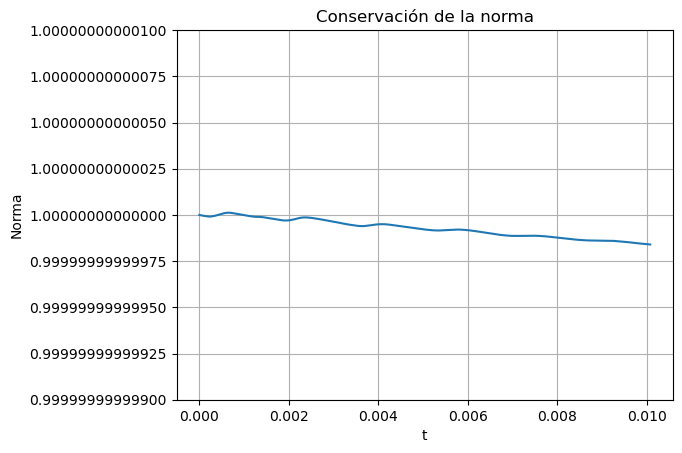

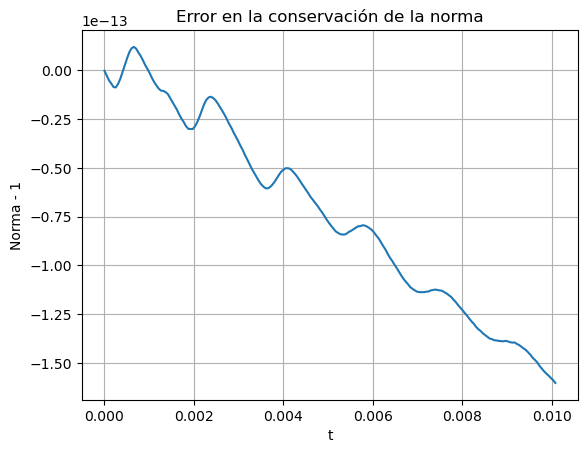

In [8]:
# ============================================================
# 7. GRÁFICA DE LA NORMA
# ============================================================

plt.figure()
plt.plot(tiempos, normas)
plt.xlabel("t")
plt.ylabel("Norma")
plt.title("Conservación de la norma")
plt.ticklabel_format(useOffset=False)
plt.ylim(0.999999999999, 1.000000000001)
plt.grid()
plt.show()

plt.figure()
plt.plot(tiempos, normas - 1)
plt.xlabel("t")
plt.ylabel("Norma - 1")
plt.title("Error en la conservación de la norma")
plt.grid()
plt.show()

**8. Animación de la densidad de probabilidad $|\Phi|^2$**

Se genera una animación de la densidad de probabilidad $|\Phi(x,t)|^2$ para observar la evolución temporal del sistema. Esto permite visualizar de forma dinámica cómo el paquete de ondas se desplaza, colisiona con la barrera central y se divide en una componente reflejada y otra transmitida. Además, se superpone el contorno del potencial reescalado para identificar la posición física de la barrera cuadrada.

GIF guardado en:
C:\Users\claud\schrodinger_obligatorio.gif


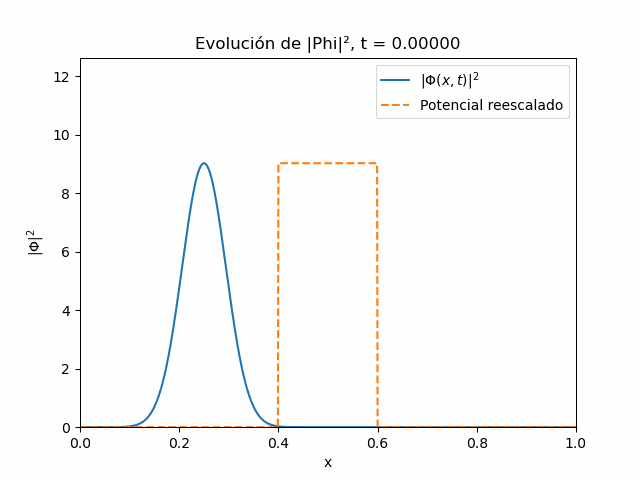

In [9]:
# ============================================================
# 8. ANIMACIÓN DE |PHI|²
# ============================================================

fig, ax = plt.subplots()

prob0 = np.abs(phis[0])**2
prob_max = np.max(prob0)

linea, = ax.plot(x, prob0, label=r"$|\Phi(x,t)|^2$")

if np.max(V_tilde) > 0:
    ax.plot(
        x,
        V_tilde / np.max(V_tilde) * prob_max,
        "--",
        label="Potencial reescalado"
    )

ax.set_xlim(0, L)
ax.set_ylim(0, prob_max * 1.4)
ax.set_xlabel("x")
ax.set_ylabel(r"$|\Phi|^2$")
ax.legend()

def actualizar(frame):
    prob = np.abs(phis[frame])**2
    linea.set_ydata(prob)
    ax.set_title(f"Evolución de |Phi|², t = {tiempos[frame]:.5f}")
    return linea,

anim = FuncAnimation(
    fig,
    actualizar,
    frames=len(phis),
    interval=40,
    blit=True
)

nombre_gif = "schrodinger_obligatorio.gif"

anim.save(nombre_gif, writer=PillowWriter(fps=25))

plt.close(fig)

print("GIF guardado en:")
print(os.path.abspath(nombre_gif))

display(Image(filename=nombre_gif))

**9. Coeficientes de reflexión y transmisión**

Se calcula la densidad de probabilidad final $|\Phi|^2$ para estimar la probabilidad de encontrar la partícula en tres regiones del espacio: a la izquierda de la barrera, dentro de ella y a su derecha. Estas sumas aproximan los coeficientes de reflexión ($R$), la permanencia en la barrera ($B$) y la transmisión ($T$). Para mantener la validez física, la medición debe realizarse tras la interacción completa con el potencial, pero antes de que el paquete transmitido impacte contra la pared derecha del pozo.

In [10]:
# ============================================================
# 9. COEFICIENTES DE TRANSMISIÓN, REFLEXIÓN Y BARRERA
# ============================================================

phi_final = phis[-1]
prob_final = np.abs(phi_final)**2

R = np.sum(prob_final[:j1] * h)
B = np.sum(prob_final[j1:j2] * h)
T = np.sum(prob_final[j2:] * h)

print("Coeficiente de reflexión aproximado R =", R)
print("Probabilidad dentro de la barrera B =", B)
print("Coeficiente de transmisión aproximado T =", T)
print("R + B + T =", R + B + T)
print("Norma final =", np.sum(prob_final) * h)

Coeficiente de reflexión aproximado R = 0.5081548994860765
Probabilidad dentro de la barrera B = 0.1698899558010153
Coeficiente de transmisión aproximado T = 0.3219551447127481
R + B + T = 0.9999999999998399
Norma final = 0.9999999999998398


# Resultados y discusión

En esta fase se han analizado los resultados obtenidos a partir de la simulación numérica de la ecuación de Schrödinger.

En primer lugar, se ha comprobado que la norma de la función de onda se mantiene aproximadamente constante a lo largo de toda la evolución temporal. Este resultado es fundamental, ya que garantiza la correcta interpretación probabilística del sistema y confirma que el método de Cayley implementado es unitario.

Además, las simulaciones muestran un comportamiento físico coherente, observándose una evolución suave y estable de la función de onda. No se aprecian inestabilidades numéricas ni divergencias, lo que indica que la discretización espacial y temporal elegida es adecuada.

Por otro lado, la evolución temporal obtenida es consistente con lo esperado teóricamente, lo que valida la implementación del Hamiltoniano y del esquema de diferencias finitas utilizado para aproximar las derivadas.

En conjunto, estos resultados permiten afirmar que el algoritmo desarrollado reproduce correctamente la dinámica del sistema cuántico, constituyendo una base sólida para el estudio más avanzado realizado en la fase voluntaria.

# Conclusión

La fase obligatoria ha permitido implementar y validar un método numérico eficaz para la resolución de la ecuación de Schrödinger dependiente del tiempo.

Se ha comprobado que el esquema utilizado conserva la norma de la función de onda y proporciona resultados físicamente consistentes y estables. Este paso resulta esencial, ya que garantiza la fiabilidad del método antes de abordar simulaciones más complejas.

Por tanto, esta fase constituye un requisito previo imprescindible para el desarrollo de la parte voluntaria, donde se realiza un análisis más completo del sistema y de sus propiedades físicas.
## Conexión con la Fase Voluntaria

Una vez validado el método numérico y comprobada su estabilidad, el sistema está preparado para realizar un análisis más completo en la fase voluntaria.

En particular, la correcta implementación del algoritmo de evolución temporal permite estudiar con fiabilidad distintos estados cuánticos, calcular observables físicos y analizar su comportamiento dinámico.

Los resultados obtenidos en esta fase, como la conservación de la norma y la estabilidad de la evolución, constituyen la base sobre la que se desarrollará el estudio del oscilador armónico cuántico, incluyendo el análisis de autofunciones, estados no estacionarios y la comparación con el comportamiento clásico.

[Haz clic aquí para acceder a la memoria principal (Fase Voluntaria)](./VOLUNTARIO2_Schrodinger.ipynb)